In [90]:
import pandas as pd 
import numpy as np
import pubchempy as pcp
import networkx as nx
import matplotlib as plt
import seaborn as sns
import umap.umap_ as umap

from fairchem.core.datasets import AseDBDataset
from rdkit import Chem
from torch_geometric.utils import to_networkx
from pathlib import Path

# Overview: Dataset Structure

The goal of this section is to load the OPoly26 dataset and explore the data available within, including size, features, etc. 

In [4]:
# given the local dataset path, loads the first .aselmdb file
dataset_path = "../data/data0001.aselmdb" 
dataset = AseDBDataset({"src": dataset_path})

In [5]:
# perform object introspection: view attributes and methods available for this dataset 
dir(dataset)

['__abstractmethods__',
 '__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_idlen_cumulative',
 '_is_protocol',
 '_load_dataset_get_ids',
 '_metadata',
 'a2g',
 'atoms_transform',
 'config',
 'connect_db',
 'db_ids',
 'dbs',
 'get_atoms',
 'get_metadata',
 'get_relaxed_energy',
 'ids',
 'indices',
 'key_mapping',
 'lin_ref',
 'metadata_hasattr',
 'num_samples',
 'paths',
 'sample_property_metadata',
 'select_args',
 'transforms']

This dataset contains a variety of useful methods and attributes that allow users to easily access information about the compounds in this dataset. Below, we explore some of these attributes and methods to get a better understanding of the dataset and available methods and attributes: 

In [6]:
# allows users to easily get information about the number of compounds in this dataset 
num_samples = dataset.num_samples
print(f"Number of samples in dataset: {num_samples}")

Number of samples in dataset: 49835


In [7]:
# returns the ids of all compounds in the dataset as a list
ids = dataset.ids

print(f"ids: {ids[:10]}") # print with truncated output; 7000 entries 
print(type(ids))

ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
<class 'list'>


In [20]:
# using index, allows users to access compounds by id/index
# below, we retrieve the first compound in the dataset and introspect 
atom0 = dataset.get_atoms(0)

dir(atom0)

['__add__',
 '__ase_optimizable__',
 '__class__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_ase_handles_dynamic_stress',
 '_calc',
 '_celldisp',
 '_cellobj',
 '_centering_as_array',
 '_constraints',
 '_del_constraints',
 '_get_atomic_numbers',
 '_get_constraints',
 '_get_positions',
 '_masked_rotate',
 '_pbc',
 '_set_positions',
 'append',
 'arrays',
 'ase_objtype',
 'calc',
 'cell',
 'center',
 'constraints',
 'copy',
 'edit',
 'euler_rotate',
 'extend',
 'fromdict',
 'get_all_distances',
 'get_angle',
 'get_angles',
 'get_angular_momentum',
 'get_array',
 'get_at

In [21]:
# convient function for retrieving molecule properties as a python dictionary 
atom0_dict = atom0.todict()
atom0_dict

{'numbers': array([6, 6, 7, 1, 1, 1, 1, 1, 1, 8, 6, 8, 6, 1, 1, 1]),
 'positions': array([[-1.589337,  1.460572,  0.026373],
        [ 0.331053,  2.659752, -0.66769 ],
        [-0.276707,  1.542791, -0.573745],
        [-1.550944,  0.981078,  1.031364],
        [-2.254733,  0.825487, -0.609647],
        [-1.967295,  2.475794,  0.130037],
        [-0.216187,  3.586012, -0.340089],
        [ 1.411995,  2.73863 , -0.935431],
        [ 0.278158,  0.56333 , -0.788749],
        [-0.06004 , -0.695168,  1.281254],
        [ 0.41932 , -1.34129 ,  0.349348],
        [ 0.595508, -0.819178, -0.849667],
        [ 0.758989, -2.82702 ,  0.415845],
        [ 1.477052, -3.155407, -0.348959],
        [ 1.137376, -3.040219,  1.438005],
        [-0.182364, -3.37156 ,  0.243737]]),
 'cell': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 'pbc': array([False, False, False]),
 'info': {'source': 'omol/solvated_protein/outputs_240923/spf_165066_0_1/step0/orca.tar.zst',
  'reference_source'

Compounds are stored in this dataset as Atoms objects. Calling `get_atoms()` creates an instance of the Atoms class, which contains all the information for the specified compound. In a later section, we will further explore the attributes and methods available within each class. We will continue with the main dataset for now.

The `.a2g` method for this dataset is interesting. It is an instance of the `AtomsToGraphs` class, with some pre-defined parameters. We will explore this further, as the ability to represent molecules as graph objects will be useful for machine learning applications. 

In [11]:
help(dataset.a2g)

Help on AtomsToGraphs in module fairchem.core.preprocessing.atoms_to_graphs object:

class AtomsToGraphs(builtins.object)
 |  AtomsToGraphs(max_neigh: 'int' = 200, radius: 'int' = 6, r_energy: 'bool' = False, r_forces: 'bool' = False, r_distances: 'bool' = False, r_edges: 'bool' = True, r_fixed: 'bool' = True, r_pbc: 'bool' = False, r_stress: 'bool' = False, r_data_keys: 'Sequence[str] | None' = None, molecule_cell_size: 'float | None' = None) -> 'None'
 |  
 |  A class to help convert periodic atomic structures to graphs.
 |  
 |  The AtomsToGraphs class takes in periodic atomic structures in form of ASE atoms objects and converts
 |  them into graph representations for use in PyTorch. The primary purpose of this class is to determine the
 |  nearest neighbors within some radius around each individual atom, taking into account PBC, and set the
 |  pair index and distance between atom pairs appropriately. Lastly, atomic properties and the graph information
 |  are put into a PyTorch ge

In [12]:
# AtomsToGraphs: converts periodic atomic structures to graphs
# input: ASE atoms objects 
# return: list of torch geometric data objects w/ mol graph info -> use with pytorch 

a2g = dataset.a2g # initialize instance of AtomsToGraph converter

# to access pre-defined attributes for this class: 
print(f"Max Neighbors: {a2g.max_neigh}") # dir(a2g) for more attributes

# data = a2g.convert(dataset.get_atoms(0))
# print(data.edge_stores[0])

# G = to_networkx(data, to_undirected=True)

# plt.figure(figsize=(8, 8))
# pos = nx.spring_layout(G)  
# nx.draw(G, pos, with_labels=True)
# plt.title("atom0")
# plt.show()

Max Neighbors: 200


# Working with the Dataset 
Now that we have a better understanding of the dataset, we can begin to work with it. For convienice, we will convert our dataset into a Pandas DataFrame. We will first define a helper function to help with this: 

In [ ]:
file_path = "../data/data0002.aselmdb" 

def convert_aselmdb_df(file_path):
    '''Convers the contents of a single aselmdb file to a pandas df.'''

    # retrieves dataset 
    dataset = AseDBDataset({"src": file_path})
    rows = list(map(lambda idx: dataset.get_atoms(idx).info, range(len(dataset))))
    return pd.DataFrame(rows) 

In [94]:
files = list(Path("../data").rglob("*.aselmdb"))
file_subset = files[:40]

In [95]:
df_list = [convert_aselmdb_df(f) for f in file_subset]
df1 = pd.concat(df_list, ignore_index=True)

TypeError: 'PosixPath' object is not iterable

In [15]:
df = convert_aselmdb_df(file_path=file_path)

In [16]:
df.head()

,source,reference_source,data_id,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,...,s_squared,s_squared_dev,warnings,mulliken_charges,lowdin_charges,nbo_charges,composition,mulliken_spins,lowdin_spins,nbo_spins
0,ani2x/ani2x_005_9110_0_1/orca.tar.zst,NaN,ani2x,0,1,5,18,0,11,104,...,0.0,0.0,[B97M-V or wB97M-V functional requested.libXC ...,"[0.313088, 0.2544, 0.259138, -0.459795, -0.366...","[0.122594, 0.064767, 0.064591, -0.064201, -0.1...","[0.43704, 0.31231, 0.3144, -0.49252, -0.57123]",H3N1O1,NaN,NaN,NaN
1,pdb_fragments_400K/6ouv_ABS01_state0_-4_1_ZINC...,NaN,biomolecules,0,1,151,580,0,14,3532,...,0.0,0.0,[B97M-V or wB97M-V functional requested.libXC ...,"[-1.305558, 0.762014, -0.65693, 0.30367, 0.379...","[0.002997, -0.548874, 0.043155, 0.097783, 0.08...",NaN,C48H75N15O12S1,NaN,NaN,NaN
2,trans1x/t1x_rxn3051_866_549_0_1/orca.tar.zst,NaN,trans1x,0,1,16,50,0,16,318,...,0.0,0.0,[B97M-V or wB97M-V functional requested.libXC ...,"[-0.690696, -0.601276, 0.588356, -1.492559, -0...","[0.032462, -0.196624, -0.388111, -0.04229, -0....","[-0.27357, -0.57773, 0.06623, -0.6259, -0.1035...",C4H10O2,"[3.3e-05, -4.6e-05, 9e-06, 1.1e-05, -1e-05, -0...","[2.6e-05, -3.5e-05, 5e-06, -1e-06, -1e-06, 1e-...","[3e-05, -4e-05, 1e-05, 0.0, 0.0, 0.0, 0.0, 1e-..."
3,omol/solvated_protein/outputs_240923/spf_15030...,NaN,biomolecules,0,1,20,56,0,12,376,...,0.0,0.0,[B97M-V or wB97M-V functional requested.libXC ...,"[-1.330622, -0.225007, -0.796761, 0.46705, -1....","[-0.124373, -0.24006, -0.170375, -0.390637, 0....","[-0.60813, -0.4001, -0.45705, 0.20675, -0.5073...",C6H13N1,NaN,NaN,NaN
4,omol/electrolytes/solvated_090624/carboxylate_...,NaN,elytes,0,1,104,384,0,14,2294,...,0.0,0.0,[B97M-V or wB97M-V functional requested.libXC ...,"[-0.999337, -0.371996, -1.144993, -0.303656, 0...","[-0.039235, -0.271339, -0.038717, -0.039748, -...",NaN,C34Cl1H57N3O7P1Si1,NaN,NaN,NaN


In [23]:
df_cols = df.columns
print(f'Number of cols = {len(df_cols)}')
print(f'Column names: {df_cols}')

Number of cols = 25
Column names: Index(['source', 'reference_source', 'data_id', 'charge', 'spin', 'num_atoms',
       'num_electrons', 'num_ecp_electrons', 'n_scf_steps', 'n_basis',
       'unrestricted', 'nl_energy', 'integrated_densities', 'homo_energy',
       'homo_lumo_gap', 's_squared', 's_squared_dev', 'warnings',
       'mulliken_charges', 'lowdin_charges', 'nbo_charges', 'composition',
       'mulliken_spins', 'lowdin_spins', 'nbo_spins'],
      dtype='str')


In [57]:
# not all data cols are useful (administrative details); we will drop them
cols_to_drop = ['source', 'warnings', 'reference_source', 'unrestricted']

new_df = df.drop(columns = cols_to_drop)
new_df.head() 

,data_id,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,integrated_densities,...,homo_lumo_gap,s_squared,s_squared_dev,mulliken_charges,lowdin_charges,nbo_charges,composition,mulliken_spins,lowdin_spins,nbo_spins
0,ani2x,0,1,5,18,0,11,104,2.014511,"[8.999988934292, 8.999988934292, 17.999977868584]",...,[11.245731136448324],0.0,0.0,"[0.313088, 0.2544, 0.259138, -0.459795, -0.366...","[0.122594, 0.064767, 0.064591, -0.064201, -0.1...","[0.43704, 0.31231, 0.3144, -0.49252, -0.57123]",H3N1O1,NaN,NaN,NaN
1,biomolecules,0,1,151,580,0,14,3532,58.164885,"[289.999942712756, 289.999942712756, 579.99988...",...,[8.219090303116028],0.0,0.0,"[-1.305558, 0.762014, -0.65693, 0.30367, 0.379...","[0.002997, -0.548874, 0.043155, 0.097783, 0.08...",NaN,C48H75N15O12S1,NaN,NaN,NaN
2,trans1x,0,1,16,50,0,16,318,5.215182,"[25.00000933864, 25.000009338439, 50.00001867708]",...,"[10.520466064740862, 10.520493276126889]",0.0,0.0,"[-0.690696, -0.601276, 0.588356, -1.492559, -0...","[0.032462, -0.196624, -0.388111, -0.04229, -0....","[-0.27357, -0.57773, 0.06623, -0.6259, -0.1035...",C4H10O2,"[3.3e-05, -4.6e-05, 9e-06, 1.1e-05, -1e-05, -0...","[2.6e-05, -3.5e-05, 5e-06, -1e-06, -1e-06, 1e-...","[3e-05, -4e-05, 1e-05, 0.0, 0.0, 0.0, 0.0, 1e-..."
3,biomolecules,0,1,20,56,0,12,376,5.797387,"[27.999995730034, 27.999995730034, 55.99999146...",...,[9.768860371361816],0.0,0.0,"[-1.330622, -0.225007, -0.796761, 0.46705, -1....","[-0.124373, -0.24006, -0.170375, -0.390637, 0....","[-0.60813, -0.4001, -0.45705, 0.20675, -0.5073...",C6H13N1,NaN,NaN,NaN
4,elytes,0,1,104,384,0,14,2294,39.429374,"[192.000010249452, 192.000010249452, 384.00002...",...,[8.543640504228657],0.0,0.0,"[-0.999337, -0.371996, -1.144993, -0.303656, 0...","[-0.039235, -0.271339, -0.038717, -0.039748, -...",NaN,C34Cl1H57N3O7P1Si1,NaN,NaN,NaN


In [58]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49835 entries, 0 to 49834
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   data_id               49835 non-null  str    
 1   charge                49835 non-null  int64  
 2   spin                  49835 non-null  int64  
 3   num_atoms             49835 non-null  int64  
 4   num_electrons         49835 non-null  int64  
 5   num_ecp_electrons     49835 non-null  int64  
 6   n_scf_steps           49835 non-null  int64  
 7   n_basis               49835 non-null  int64  
 8   nl_energy             49835 non-null  float64
 9   integrated_densities  49835 non-null  object 
 10  homo_energy           49835 non-null  object 
 11  homo_lumo_gap         49835 non-null  object 
 12  s_squared             49835 non-null  float64
 13  s_squared_dev         49835 non-null  float64
 14  mulliken_charges      49835 non-null  object 
 15  lowdin_charges        49834 no

In [66]:
# some data fields will need to be encoded (i.e., data_id); let's take a closer look

data_ids = new_df['data_id']
print(f"Num unique molecule types: {data_ids.nunique()}")
print(f"Unique molecules = {data_ids.unique()}")

df_encoded = pd.get_dummies(new_df, columns = ['data_id'], dtype=int)
df_encoded

Num unique molecule types: 10
Unique molecules = <StringArray>
[          'ani2x',    'biomolecules',         'trans1x',          'elytes',
      'reactivity',      'geom_orca6', 'metal_complexes',             'rgd',
   'orbnet_denali',           'spice']
Length: 10, dtype: str


,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,integrated_densities,homo_energy,...,data_id_ani2x,data_id_biomolecules,data_id_elytes,data_id_geom_orca6,data_id_metal_complexes,data_id_orbnet_denali,data_id_reactivity,data_id_rgd,data_id_spice,data_id_trans1x
0,0,1,5,18,0,11,104,2.014511,"[8.999988934292, 8.999988934292, 17.999977868584]",[-10.490016523779596],...,1,0,0,0,0,0,0,0,0,0
1,0,1,151,580,0,14,3532,58.164885,"[289.999942712756, 289.999942712756, 579.99988...",[-8.285703776103679],...,0,1,0,0,0,0,0,0,0,0
2,0,1,16,50,0,16,318,5.215182,"[25.00000933864, 25.000009338439, 50.00001867708]","[-9.450405520718647, -9.450432732104671]",...,0,0,0,0,0,0,0,0,0,1
3,0,1,20,56,0,12,376,5.797387,"[27.999995730034, 27.999995730034, 55.99999146...",[-8.674119100215497],...,0,1,0,0,0,0,0,0,0,0
4,0,1,104,384,0,14,2294,39.429374,"[192.000010249452, 192.000010249452, 384.00002...",[-8.21149832641523],...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49830,1,3,21,92,0,18,512,9.611656,"[47.000006088215, 45.000005689605, 92.00001177...","[-10.79010368885632, -14.849852003989742]",...,0,0,0,0,0,0,1,0,0,0
49831,-2,4,64,353,0,7,1786,35.569880,"[177.999991771097, 175.000001321793, 352.99999...","[1.5827774794933451, -1.1370277650281853]",...,0,0,0,0,1,0,0,0,0,0
49832,0,1,7,64,28,27,237,6.791255,"[31.999959550659, 31.9999585839, 63.999918134559]","[-9.281722138753594, -9.328716202417676]",...,0,0,0,0,0,0,1,0,0,0
49833,1,1,16,50,0,17,290,5.268865,"[25.000002503044, 25.000002503079, 50.00000500...","[-15.719555112714541, -15.719527901328519]",...,0,0,0,0,0,0,1,0,0,0


In [67]:
num_df = df_encoded.select_dtypes(include=['number'])
num_df.head()

,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,s_squared,s_squared_dev,data_id_ani2x,data_id_biomolecules,data_id_elytes,data_id_geom_orca6,data_id_metal_complexes,data_id_orbnet_denali,data_id_reactivity,data_id_rgd,data_id_spice,data_id_trans1x
0,0,1,5,18,0,11,104,2.014511,0.0,0.0,1,0,0,0,0,0,0,0,0,0
1,0,1,151,580,0,14,3532,58.164885,0.0,0.0,0,1,0,0,0,0,0,0,0,0
2,0,1,16,50,0,16,318,5.215182,0.0,0.0,0,0,0,0,0,0,0,0,0,1
3,0,1,20,56,0,12,376,5.797387,0.0,0.0,0,1,0,0,0,0,0,0,0,0
4,0,1,104,384,0,14,2294,39.429374,0.0,0.0,0,0,1,0,0,0,0,0,0,0


Text(0.5, 1.0, 'Correlation Heatmap')

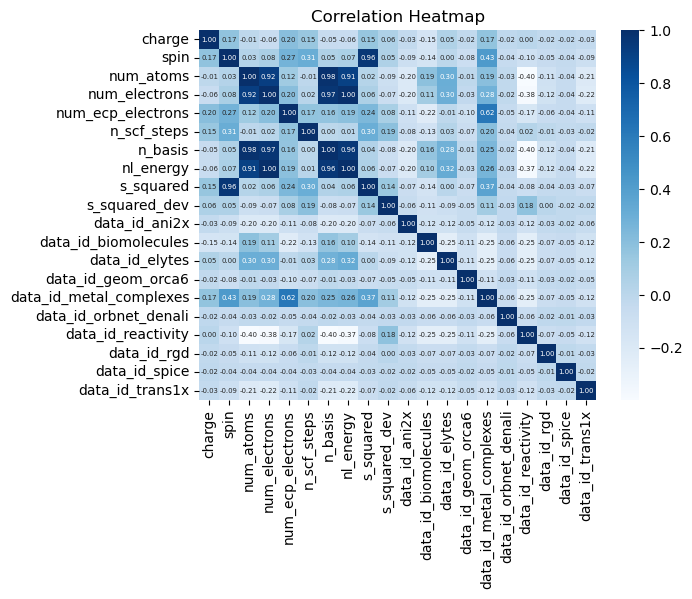

In [87]:
ax = sns.heatmap(num_df.corr(), annot=True, annot_kws = {'size': 5}, fmt = '.2f', cmap='Blues')
ax.set_title("Correlation Heatmap")